# HJM kernel covariance — derivation & walk-through

The `hjm_kernel` estimator replaces a noisy ~$n^2/2$-entry sample covariance with a smooth,
positive-semidefinite covariance generated by a $k$-factor **Gaussian HJM** (Hull–White / LGM)
model, fitting only $2k+\binom{k}{2}$ parameters.

This notebook (1) derives the covariance functional form from the model assumptions, (2) reproduces
**step by step** what [`src/estimators/hjm_kernel.py`](../src/estimators/hjm_kernel.py) does on real curve
data, and (3) studies how the fit depends on the number of factors $k$.

## 1. Gaussian HJM setup

The instantaneous forward rate $f(t,T)$ (the rate seen at $t$ for a future date $T\ge t$) follows

$$df(t,T)=\mu(t,T)\,dt+\sigma(t,T)\,dW_t .$$

* **Gaussian HJM:** $\sigma(t,T)$ is *deterministic*, so $f$ is Gaussian and fully characterized by
  its mean and covariance.
* **The drift is irrelevant to the covariance.** $\mu$ is pinned by no-arbitrage, but over $[t,t+dt]$
  it contributes an $O(dt)$ term to the increment whose effect on a covariance is $O(dt^2)$ — negligible
  against the $O(dt)$ diffusion. We keep only the diffusion.

## 2. Separability forces exponential loadings

Require the model to be **Markovian in a finite-dimensional state** — exactly what collapses the
covariance onto a few parameters. That needs $\sigma$ **separable** in calendar time and maturity,
$\sigma(t,T)=h(t)H(T)$. Pulling out the value at $T=t$,

$$\sigma(t,T)=\underbrace{h(t)H(t)}_{\sigma(t)}\cdot\underbrace{\tfrac{H(T)}{H(t)}}_{G(t,T)},\qquad G(t,t)=1 .$$

**Time-homogeneity** (decay depends only on the gap $\tau=T-t$, so a constant-maturity panel is
stationary) requires $H(T)/H(t)=G(T-t)$. Composing over $t_1\le t_2\le t_3$ gives the multiplicative
Cauchy equation

$$G(a+b)=G(a)\,G(b),\quad G(0)=1\ \Longrightarrow\ G(\tau)=e^{-\lambda\tau}\ (\lambda>0).$$

Hence the **Hull–White / LGM** volatility
$$\boxed{\ \sigma(t,T)=\sigma(t)\,e^{-\lambda(T-t)}\ }$$
with $\lambda$ the decay/mean-reversion speed and $\sigma(t)$ the time-$t$ shock scale.

## 3. Multi-factor superposition

A single exponential is too rigid (§6 shows it forces unit correlations). Superpose $k$ exponential
factors with correlated drivers:

$$df(t,T)=\mu\,dt+\sum_{i=1}^{k}\sigma_i(t)\,e^{-\lambda_i(T-t)}\,dW_t^{\,i},\qquad
dW_t^{\,i}\,dW_t^{\,j}=\rho_{ij}\,dt,\ \ \rho_{ii}=1 .$$

Parameters: scales $\sigma_i$, decays $\lambda_i$, driver correlations $\rho_{ij}$. For covariance
estimation $\sigma_i$ is treated as constant.

## 4. Instantaneous covariance of increments

With $\tau_a=T_a-t,\ \tau_b=T_b-t$, the deterministic diffusion coefficients pass out of the
conditional expectation and $\mathbb E_t[dW^i dW^j]=\rho_{ij}\,dt$ gives the **instantaneous covariance
rate**

$$\boxed{\ C(\tau_a,\tau_b)=\sum_{i=1}^{k}\sum_{j=1}^{k}\rho_{ij}\,\sigma_i\sigma_j\,
e^{-\lambda_i\tau_a-\lambda_j\tau_b}\ }$$

a smooth surface over $(\tau_a,\tau_b)$ controlled entirely by $\theta=\{\sigma_i,\lambda_i,\rho_{ij}\}$.
This is the object fitted to the empirical covariance.

## 5. Matrix form $C=APA^\top$

For a tenor grid $\tau_1,\dots,\tau_n$ let $E_{ai}=e^{-\lambda_i\tau_a}$ $(n\times k)$,
$D=\mathrm{diag}(\sigma_i)$, $P=[\rho_{ij}]$. With $A=ED$ (so $A_{ai}=\sigma_i e^{-\lambda_i\tau_a}$),

$$\mathbf C = A\,P\,A^\top .$$

* **Symmetric** by construction.
* **Positive semidefinite** whenever $P$ is — the model can never emit an invalid covariance.
* **Rank $\le k$** — $k$ is the effective dimensionality.
* **Linear in $P$, nonlinear only through the $\lambda_i$** inside $E$.

## 6. Sanity checks

**Variance term structure** (diagonal): $C(\tau,\tau)=\sum_{ij}\rho_{ij}\sigma_i\sigma_j
e^{-(\lambda_i+\lambda_j)\tau}$ — a sum of exponentials in $\tau$; fitting this 1-D curve is a good way
to seed the $\lambda_i$.

**Correlation surface:** $\mathrm{Corr}(\tau_a,\tau_b)=C(\tau_a,\tau_b)/\sqrt{C(\tau_a,\tau_a)C(\tau_b,\tau_b)}$.
The overall scale and common decay cancel, so correlation depends only on the *ratios* $\sigma_i/\sigma_1$,
the *differences* $\lambda_i-\lambda_1$, and $\rho_{ij}$.

**One factor is degenerate:** $C=\sigma_1^2 e^{-\lambda_1\tau_a}e^{-\lambda_1\tau_b}$ is rank-1, so
$\mathrm{Corr}\equiv 1$ — every tenor perfectly correlated. Hence $k\ge 2$; $k=3$ (level / slope /
curvature) is the textbook rates choice. We confirm both numerically in §9.

## 7. From continuous time to the fitted target

Over a finite step $\Delta t$ the coefficients are ~frozen, so
$\mathrm{Cov}(\Delta f(\tau_a),\Delta f(\tau_b))\approx C(\tau_a,\tau_b)\,\Delta t$. Sampling at fixed
time-to-maturity makes the pooled daily increments stationary. We fit $\theta$ so
$C_\theta(\tau_a,\tau_b)\approx\hat\Sigma_{ab}$ over the grid. The estimator fits the **per-day** sample
covariance directly (it does not divide by $\Delta t$), so the $\Delta t$ is absorbed into the $\sigma_i$
and the result stays on the same scale as the other estimators on the dashboard.

## 8. Step by step: what `hjm_kernel.py` does

The cells below reproduce the estimator's internals explicitly so each piece of the optimization is
visible, then cross-check against the production class.

In [1]:
import sys
from pathlib import Path

# Make the project package importable regardless of where Jupyter was launched.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(ROOT))

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

from src.data_loader import load_rates
from src.tenor_graph import tenor_to_years

INPUTS = ROOT / "inputs"
np.set_printoptions(precision=4, suppress=True)

### 8.1 Load data → sample covariance $\hat\Sigma$ and the $\tau$ grid

The fit target is the sample covariance of **daily par-rate changes**; the $\tau$ grid is each tenor's
time-to-maturity in years, read straight from the column labels via `tenor_to_years`.

In [2]:
CURVE   = "CAD"
rates   = load_rates(INPUTS / CURVE / "curve_data.csv")
changes = rates.diff().dropna()                            # daily increments Δf
S       = np.cov(changes.values.T)                         # empirical target  (n, n)
tau     = np.array([tenor_to_years(c) for c in rates.columns])   # time-to-maturity grid
n       = len(tau)

print(f"{changes.shape[0]} daily changes x {n} tenors")
print("tenors:", list(rates.columns))
print("tau (yrs):", tau)

261 daily changes x 15 tenors
tenors: ['3M', '6M', '9M', '1Y', '18M', '2Y', '3Y', '4Y', '5Y', '7Y', '10Y', '15Y', '20Y', '25Y', '30Y']
tau (yrs): [ 0.25  0.5   0.75  1.    1.5   2.    3.    4.    5.    7.   10.   15.
 20.   25.   30.  ]


### 8.2 Unconstrained reparameterization

The optimizer searches over a free vector $\theta$; constraints hold *automatically* through the mapping:

* $\sigma_i=e^{s_i}>0$,
* $\lambda_i=\sum_{j\le i}\mathrm{softplus}(\ell_j)$ — positive **and** increasing, which removes the
  factor-relabeling symmetry,
* a lower-triangular $L$ with **unit-norm rows** gives $P=LL^\top$, a valid correlation matrix
  (unit diagonal, $|\rho|<1$).

In [3]:
def softplus(x):
    return np.logaddexp(0.0, x)

def unpack(theta, k):
    sigma = np.exp(theta[:k])                          # σ_i = exp(s_i) > 0
    lam   = np.cumsum(softplus(theta[k:2*k]))          # λ_i increasing & > 0
    L = np.eye(k)
    L[np.tril_indices(k, -1)] = theta[2*k:]
    L /= np.linalg.norm(L, axis=1, keepdims=True)      # unit rows -> P = L Lᵀ is a correlation matrix
    return sigma, lam, L @ L.T

# a random theta still yields a valid parameter set:
sig_, lam_, P_ = unpack(np.array([-3.0, -3.0, 0.0, 0.0, 0.5]), k=2)
print("sigma ", sig_)
print("lambda", lam_)
print("P\n", P_)
print("valid correlation (unit diag):", np.allclose(np.diag(P_), 1.0))

sigma  [0.0498 0.0498]
lambda [0.6931 1.3863]
P
 [[1.     0.4472]
 [0.4472 1.    ]]
valid correlation (unit diag): True


### 8.3 The model $C=APA^\top$ and the weighted-Frobenius objective

We fit each unique entry once (upper triangle). `weighting="uniform"` matches covariance *levels*;
`weighting="corr"` divides residuals by $\sqrt{\hat\Sigma_{aa}\hat\Sigma_{bb}}$ to fit the correlation
*shape* instead of being dominated by the high-variance long end.

In [4]:
def model(theta, k):
    sigma, lam, P = unpack(theta, k)
    A = sigma * np.exp(-np.outer(tau, lam))    # A[a,i] = σ_i e^{-λ_i τ_a},  shape (n, k)
    return A @ P @ A.T

iu     = np.triu_indices(n)                    # unique (a, b) entries
target = S[iu]

def resid(theta, k, sw):
    return sw * (model(theta, k)[iu] - target)

### 8.4 Initialization

The objective is non-convex, so a good start matters. We spread the decays $\lambda_i$ geometrically
from slow (a whole-curve *level* move, $\lambda\approx 1/\tau_{\max}$) to fast (a *short-end* move,
$\lambda\approx 1/\tau_{\min}$), set every $\sigma_i$ to a fraction of the average diagonal, and start
the factors uncorrelated ($P=I$).

In [5]:
def init(k, jitter, rng):
    sigma0 = np.sqrt(max(np.diag(S).mean(), 1e-12) / k)
    s0   = np.full(k, np.log(sigma0))
    incr = np.maximum(np.diff(np.geomspace(1/tau.max(), 1/tau.min(), k), prepend=0.0), 1e-6)
    l0   = np.log(np.expm1(incr))              # softplus inverse of the per-factor λ increments
    theta0 = np.concatenate([s0, l0, np.zeros(k*(k-1)//2)])
    return theta0 + rng.normal(scale=0.5, size=theta0.shape) if jitter else theta0

print("seed λ (k=2):", np.cumsum(softplus(init(2, False, None)[2:4])))
print("seed λ (k=3):", np.cumsum(softplus(init(3, False, None)[3:6])))

seed λ (k=2): [0.0333 4.    ]
seed λ (k=3): [0.0333 0.3651 4.    ]


### 8.5 Fit by trust-region least squares (with restarts)

`scipy.optimize.least_squares` (`trf`) minimizes the residual vector. A few seeded random restarts guard
against local minima; we keep the lowest-cost solution.

In [6]:
def fit_hjm(k, weighting="uniform", n_restarts=4):
    if weighting == "corr":
        d  = np.sqrt(np.diag(S)); sw = 1.0 / np.sqrt(np.outer(d, d)[iu])
    else:
        sw = np.ones(len(target))
    rng, best = np.random.default_rng(0), None
    for r in range(n_restarts):
        sol = least_squares(resid, init(k, r > 0, rng), args=(k, sw), method="trf")
        if best is None or sol.cost < best.cost:
            best = sol
    return best

best = fit_hjm(2)
sigma, lam, P = unpack(best.x, 2)
C2 = model(best.x, 2)
print("sigma ", sigma)
print("lambda", lam)
print("P\n", P)
print("rel. Frobenius error vs sample cov: %.4f" % (np.linalg.norm(C2 - S) / np.linalg.norm(S)))

sigma  [0.0343 0.0379]
lambda [0.0048 0.3441]
P
 [[ 1.     -0.2595]
 [-0.2595  1.    ]]
rel. Frobenius error vs sample cov: 0.0381


### 8.6 Cross-check against the production estimator

Same algorithm, same seed — the manual fit reproduces `HJMKernelEstimator` exactly (default $k=2$).

In [7]:
from src.estimators import get_estimator

est    = get_estimator("hjm_kernel")        # production default: k = 2
C_prod = est.fit(changes)
print("matches manual fit:", np.allclose(C2, C_prod))
print("fitted params:", {key: np.round(v, 4) for key, v in est.params_.items() if key != "k"})

matches manual fit: True
fitted params: {'sigma': array([0.0343, 0.0379]), 'lambda': array([0.0048, 0.3441]), 'rho': array([[ 1.    , -0.2595],
       [-0.2595,  1.    ]])}


## 9. Choosing the number of factors $k$

### 9.1 How many factors does the data want?

The eigenvalue spectrum of $\hat\Sigma$ shows how concentrated the variance is. For rates, the first 2–3
PCs (level / slope / curvature) typically explain essentially all of it — motivating small $k$.

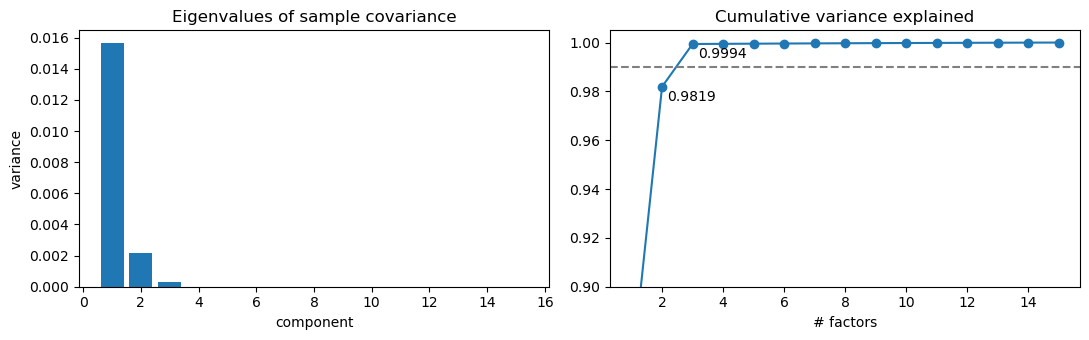

In [8]:
evals = np.linalg.eigvalsh(S)[::-1]
cum   = np.cumsum(evals) / evals.sum()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].bar(range(1, n + 1), evals)
ax[0].set(title="Eigenvalues of sample covariance", xlabel="component", ylabel="variance")
ax[1].plot(range(1, n + 1), cum, "o-"); ax[1].axhline(0.99, ls="--", c="grey")
ax[1].set(title="Cumulative variance explained", xlabel="# factors", ylim=(0.9, 1.005))
for j in (1, 2, 3):
    ax[1].annotate(f"{cum[j-1]:.4f}", (j, cum[j-1]), textcoords="offset points", xytext=(4, -10))
plt.tight_layout(); plt.show()

### 9.2 Fit quality vs $k$

Fit each $k$ and compare against the $n(n+1)/2$ free entries of the raw sample covariance. Note the rank
caps at $k$, and **$k=1$ is degenerate**: its minimum off-diagonal correlation is exactly 1.

In [9]:
def corr_of(M):
    d = np.sqrt(np.diag(M)); return M / np.outer(d, d)

ks, Cs, rows = [1, 2, 3, 4], {}, []
for k in ks:
    Cs[k] = model(fit_hjm(k).x, k)
    rows.append({
        "k": k,
        "params": 2*k + k*(k-1)//2,
        "rel_frob_err": np.linalg.norm(Cs[k] - S) / np.linalg.norm(S),
        "rank": int(np.linalg.matrix_rank(Cs[k], tol=1e-10)),
        "min_offdiag_corr": corr_of(Cs[k])[np.triu_indices(n, 1)].min(),
    })
print("raw sample covariance has", n*(n+1)//2, "free entries")
summary = pd.DataFrame(rows).set_index("k")
summary.round(4)

raw sample covariance has 120 free entries


,params,rel_frob_err,rank,min_offdiag_corr
k,,,,
1,2,0.1499,1,1.0000
2,5,0.0381,2,0.6013
3,9,0.0063,3,0.5548
4,14,0.0027,4,0.5505


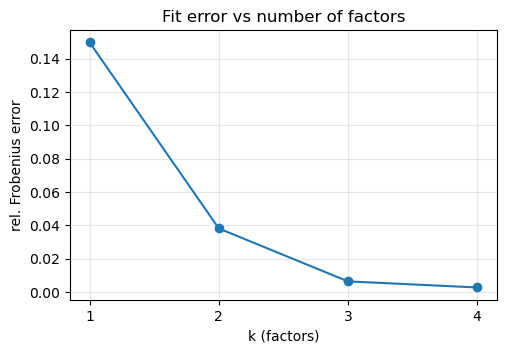

In [10]:
plt.figure(figsize=(5.5, 3.5))
plt.plot(summary.index, summary["rel_frob_err"], "o-")
plt.xticks(ks); plt.xlabel("k (factors)"); plt.ylabel("rel. Frobenius error")
plt.title("Fit error vs number of factors"); plt.grid(alpha=.3); plt.show()

### 9.3 Variance term structure: empirical vs fitted

The diagonal $C(\tau,\tau)$ is a sum of exponentials. $k=1$ cannot bend enough; $k=2$ already tracks the
empirical variances closely.

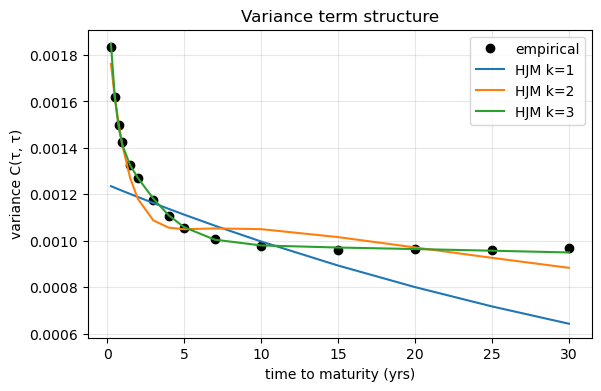

In [11]:
plt.figure(figsize=(6.5, 4))
plt.plot(tau, np.diag(S), "ko", label="empirical")
for k in (1, 2, 3):
    plt.plot(tau, np.diag(Cs[k]), "-", label=f"HJM k={k}")
plt.xlabel("time to maturity (yrs)"); plt.ylabel("variance C(τ, τ)")
plt.title("Variance term structure"); plt.legend(); plt.grid(alpha=.3); plt.show()

### 9.4 Correlation with a reference tenor

Correlation of the 2Y with every other tenor. $k=1$ is flat at 1 (the degeneracy of §6); $k\ge2$ captures
the decorrelation as tenors separate.

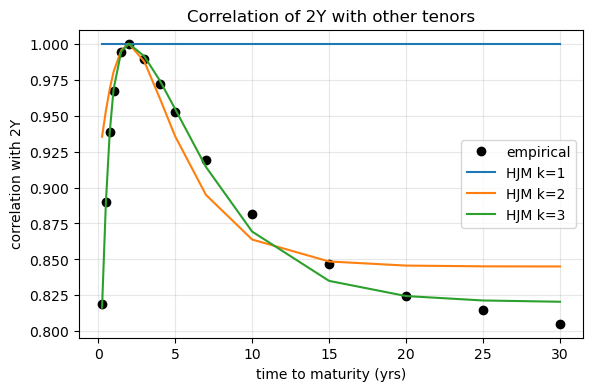

In [12]:
Cemp   = corr_of(S)
anchor = list(rates.columns).index("2Y")

plt.figure(figsize=(6.5, 4))
plt.plot(tau, Cemp[anchor], "ko", label="empirical")
for k in (1, 2, 3):
    plt.plot(tau, corr_of(Cs[k])[anchor], "-", label=f"HJM k={k}")
plt.xlabel("time to maturity (yrs)"); plt.ylabel("correlation with 2Y")
plt.title("Correlation of 2Y with other tenors"); plt.legend(); plt.grid(alpha=.3); plt.show()

### 9.5 Fitted factor shapes ($k=3$)

Each column $A_{\cdot i}=\sigma_i e^{-\lambda_i\tau}$ is one factor's loading across the curve. With the
ordering constraint the three factors come out as **level** (slow decay), **slope**, and **short-end /
curvature** (fast decay) — the classic rates decomposition.

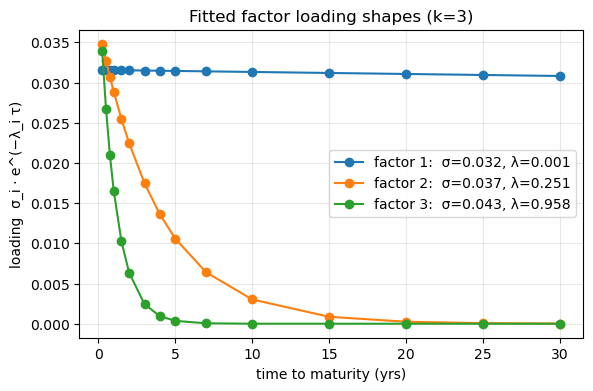

factor correlations P:
 [[ 1.    -0.052 -0.174]
 [-0.052  1.    -0.433]
 [-0.174 -0.433  1.   ]]


In [13]:
b3 = fit_hjm(3); sig3, lam3, P3 = unpack(b3.x, 3)
A3 = sig3 * np.exp(-np.outer(tau, lam3))

plt.figure(figsize=(6.5, 4))
for i in range(3):
    plt.plot(tau, A3[:, i], "o-", label=f"factor {i+1}:  σ={sig3[i]:.3f}, λ={lam3[i]:.3f}")
plt.xlabel("time to maturity (yrs)"); plt.ylabel("loading  σ_i · e^(−λ_i τ)")
plt.title("Fitted factor loading shapes (k=3)"); plt.legend(); plt.grid(alpha=.3); plt.show()
print("factor correlations P:\n", P3.round(3))

### 9.6 Weighting: levels vs correlation shape

`uniform` minimizes error on covariance *levels* (dominated by the highest-variance tenors); `corr`
divides each residual by $\sqrt{\hat\Sigma_{aa}\hat\Sigma_{bb}}$, spreading the effort evenly over the
correlation surface. On this curve the per-tenor variances span only a narrow range, so the two fits are
nearly identical — the choice matters more when variances are widely dispersed across the grid.

In [14]:
for w in ("uniform", "corr"):
    C = model(fit_hjm(2, weighting=w).x, 2)
    cov_err  = np.linalg.norm(C - S) / np.linalg.norm(S)
    corr_err = np.linalg.norm(corr_of(C) - Cemp) / np.linalg.norm(Cemp)
    print(f"{w:8s}  cov rel.err = {cov_err:.4f}   corr rel.err = {corr_err:.4f}")

uniform   cov rel.err = 0.0381   corr rel.err = 0.0372
corr      cov rel.err = 0.0385   corr rel.err = 0.0388


## 10. Why $k=2$ is the production default

The spectrum (§9.1) shows the first two factors already explain the overwhelming share of the variance
(≈98% here, against ≈86% for one factor), and §9.2 confirms $k=2$ gives a smooth, full-rank-2 PSD fit while
$k=1$ is degenerate (unit correlations). A third factor does sharpen the full-matrix fit — it adds an
explicit curvature mode (§9.5) and lifts variance-explained to ≈99.9% — but at nearly double the parameters
and a flatter, more identifiability-prone objective. $k=2$ is the most parsimonious non-degenerate choice,
so it is the estimator's default; pass `HJMKernelEstimator(k=3)` when an explicit curvature factor is
warranted.